In [1]:
import os
import pickle
import numpy as np
from tqdm import tqdm

from utils.plotting import plot_trajectories, plot_trunk_results
from utils.ssm import DelaySSM, OptSSM
from utils.systems import Trunk
from utils.models import SSMR, get_residual_labels
from utils.residual import ResidualBr, PolyBr
from utils.mpc import generate_ref_trajectory, run_mpc
from utils.misc import HyperRectangle
from utils.gusto import GuSTOConfig
import jax
import jax.numpy as jnp

from trunk_sim.data import TrunkData
from trunk_sim.policy import steady_state_input, HarmonicPolicy
from trunk_sim.rollout import rollout

INFO   2025-05-07 17:31:46 acceleratesupport No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
INFO:2025-05-07 17:31:46,385:jax._src.xla_bridge:867: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO   2025-05-07 17:31:46 xla_bridge Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
WARNING 2025-05-07 17:31:46 xla_bridge An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/patrick/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Instantiate Trunk simulator
trunk = Trunk()

  0%|          | 0/20 [00:00<?, ?it/s]

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=1.5644240032482477, angle=3.5448603880422316
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=9.712344486823387, angle=5.115656714837128


  5%|▌         | 1/20 [00:04<01:33,  4.95s/it]

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=11.36362937009434, angle=1.56432548661997
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=5.09314495796929, angle=3.135121813414867


 10%|█         | 2/20 [00:09<01:28,  4.92s/it]

...

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=11.140525845426636, angle=2.2963729612457624
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=10.552229144895787, angle=3.867169288040659


 95%|█████████▌| 19/20 [01:34<00:05,  5.15s/it]

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=11.721350874091156, angle=3.03259045821584
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=11.500656032418632, angle=4.603386785010736


100%|██████████| 20/20 [01:39<00:00,  4.99s/it]


Number of autonomous data points:  20000


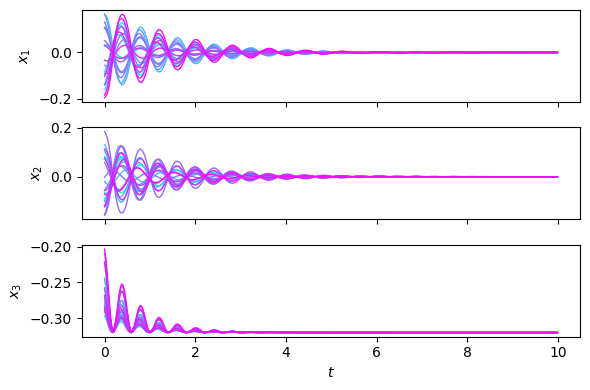

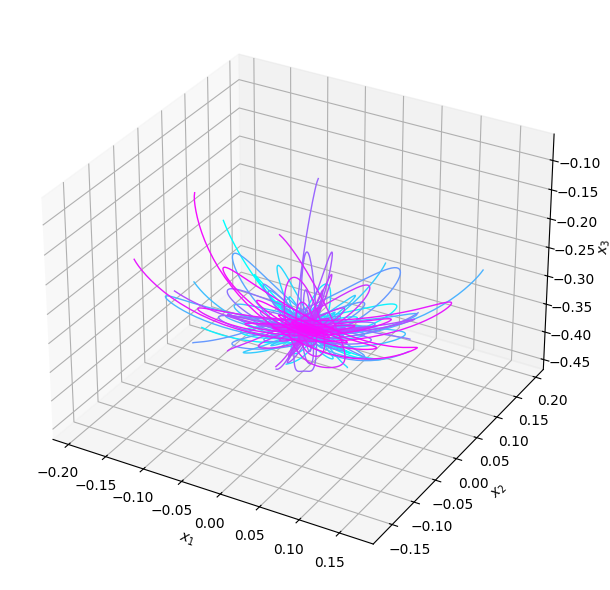

In [ ]:
# Instantiate Trunk Data class
trunk_aut_data = TrunkData(
    trunk.num_links_per_segment,
    trunk.num_segments,
    states="pos_vel",
    segments="all",
)

# Collect autonomous Trunk data
def collect_data(system: Trunk,
                 data: TrunkData,
                 num_rollouts: int = 20,
                 policy: str = "none",
                 name: str = "autonomous_data"
                 ):
    if not os.path.exists(system.data_folder):
        os.makedirs(system.data_folder)

    if system.render_video and not os.path.exists(
        os.path.join(system.data_folder, "videos")
    ):
        os.makedirs(os.path.join(system.data_folder, "videos"))

    if policy == "harmonic":
        policy = HarmonicPolicy(
            frequency_range=[0.5, 5], # Patrick has 0, 2
            amplitude_range=[0.5, 2.5], # Patrick has 0, 10
            phase_range=[0, 2 * np.pi],
            num_segments=trunk.num_segments
        )
    elif policy == "random_walk":
        policy = RandomWalkPolicy()
    elif policy == "none":
        policy = None
    else:
        raise ValueError(f"Invalid policy: {policy}")
    
    for rollout_idx in tqdm(range(num_rollouts)):

        if system.init_steady_state:
            angle = np.random.uniform(0,2*np.pi)
            sign = np.random.choice([-1,1])
            system.simulator.set_initial_steady_state(
                steady_state_input(system.simulator.num_segments, amplitude=np.random.uniform(0.0, 15.0), angle=angle),
                kick=steady_state_input(system.simulator.num_segments, amplitude=np.random.uniform(5.0, 12.5), angle=angle + np.pi/2 * sign),
                kick_duration=0.5,
            )

        rollout(
            simulator=system.simulator,
            policy=policy,
            data=data,
            duration=system.duration,
            render_video=system.render_video,
            video_filename=os.path.join(
                system.data_folder, "videos", f"rollout_{rollout_idx}.mp4"
            ),
            stop_at_convergence=system.stop_at_convergence,
            traj_ID = rollout_idx
        )

    data.save_to_csv(os.path.join(system.data_folder, name + ".csv"))

COLLECT = False
if COLLECT:
    collect_data(trunk, trunk_aut_data)
else:
    trunk_aut_data.load_from_csv(os.path.join(trunk.data_folder, "autonomous_data.csv"))
print("Number of autonomous data points: ", len(trunk_aut_data))

# Extract arrays
tss, aut_trajs, _, _ = trunk_aut_data.convert_to_arrays()

# Visualize tip trajectories
plot_trajectories(aut_trajs[:, 12:15], tss[0])

# Find optimal (oblique) linear projection and compare with orthogonal projection

In [ ]:
if False:
    N_aut_train = 10
    tip_positions = jnp.array(aut_trajs[:N_aut_train, 12:15])
    tip_velocities = jnp.array(aut_trajs[:N_aut_train, 15:18])
    aut_trajs_obs = tip_positions
    ts = tss[0]

    # Center the Z coordinate
    aut_trajs_obs = aut_trajs_obs.at[:, 2].set(aut_trajs_obs[:, 2] - jnp.mean(aut_trajs_obs[:, 2, -1]))

    ssm_opt = OptSSM(aut_trajs_obs=aut_trajs_obs,
                    t_split=3.5,
                    SSMDim=5,
                    SSMOrder=2,
                    ROMOrder=2,
                    N_delay=3,
                    ts=ts,
                    verbose=True)

    ssm_orth = DelaySSM(aut_trajs_obs=aut_trajs_obs,
                        SSMDim=5,
                        SSMOrder=2,
                        ROMOrder=2,
                        N_delay=3,
                        N_obs_delay=3,
                        orthogonalize=True,
                        ts=ts)

    # Save the SSM objects to files
    with open("ssm_opt.pkl", "wb") as f:
        pickle.dump(ssm_opt, f)

    with open("ssm_orth.pkl", "wb") as f:
        pickle.dump(ssm_orth, f)

Ipopt 3.14.6: max_iter=500
tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.6, running with linear solver MUMPS 5.2.1.

Number of nonzeros in equality constraint Jacobian...:   628950
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:  8506050

Total number of variables............................:   105160
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................: 

INFO   2025-05-07 17:43:35 ridge Transforming data
INFO   2025-05-07 17:43:35 ridge Skipping CV on ridge regression
INFO   2025-05-07 17:43:35 ridge Fitting regression model
INFO   2025-05-07 17:43:36 ridge Transforming data
INFO   2025-05-07 17:43:36 ridge Skipping CV on ridge regression
INFO   2025-05-07 17:43:36 ridge Fitting regression model
INFO   2025-05-07 17:43:36 ridge Transforming data
INFO   2025-05-07 17:43:36 ridge Skipping CV on ridge regression
INFO   2025-05-07 17:43:36 ridge Fitting regression model
INFO   2025-05-07 17:43:36 ridge Transforming data
INFO   2025-05-07 17:43:36 ridge Skipping CV on ridge regression
INFO   2025-05-07 17:43:36 ridge Fitting regression model


In [5]:
# Load the SSM objects from files
with open("ssm_opt.pkl", "rb") as f:
    ssm_opt = pickle.load(f)
with open("ssm_orth.pkl", "rb") as f:
    ssm_orth = pickle.load(f)

# Simulate controlled system
Two control inputs per joint that decompose into torque and force along the pendulum.

  0%|          | 0/30 [00:00<?, ?it/s]

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=1.180186279496448, angle=2.597095429820602
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=8.281110698651172, angle=1.0262991030257056


  3%|▎         | 1/30 [00:04<02:11,  4.54s/it]

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=0.4771548084369087, angle=4.097516910331237
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=10.03581361240554, angle=5.668313237126133


  7%|▋         | 2/30 [00:09<02:17,  4.92s/it]

...

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=13.66771810272634, angle=1.3074175492168378
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=11.161492330619115, angle=2.8782138760117344


 97%|█████████▋| 29/30 [02:46<00:06,  6.48s/it]

steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=8.287047304524323, angle=2.514366223407862
steady_state_input: num_segments=3, num_controls_per_segment=2, amplitude=12.41824718717017, angle=4.085162550202758


100%|██████████| 30/30 [02:53<00:00,  5.77s/it]


Number of controlled data points:  30000


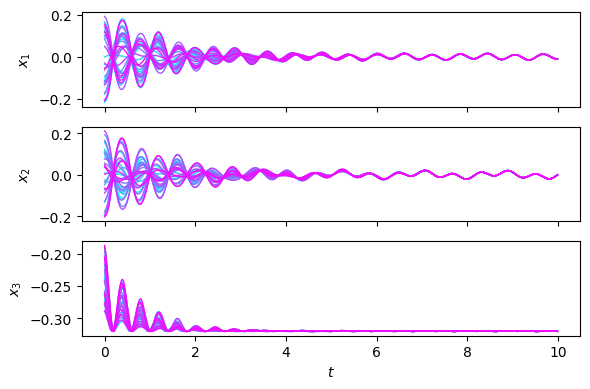

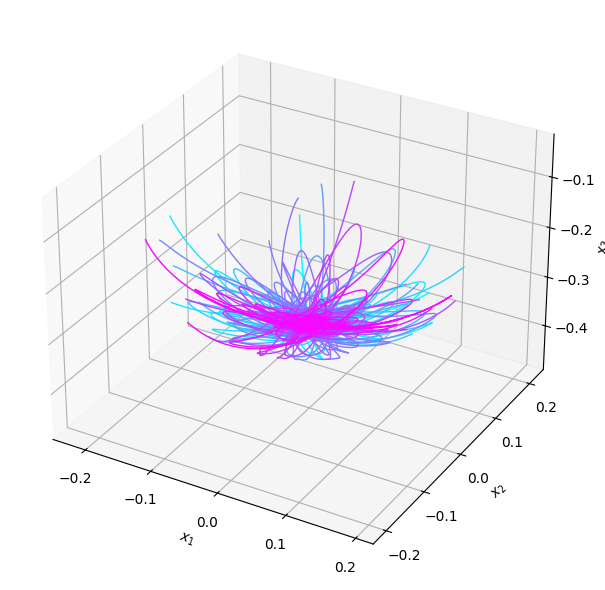

In [ ]:
# Instantiate Trunk Data class
trunk_ctrl_data = TrunkData(
    trunk.num_links_per_segment,
    trunk.num_segments,
    states="pos_vel",
    segments="all",
)

COLLECT = False
if COLLECT:
    collect_data(trunk, trunk_ctrl_data, num_rollouts=30, policy="harmonic", name="controlled_data")
else:
    trunk_ctrl_data.load_from_csv(os.path.join(trunk.data_folder, "controlled_data.csv"))
print("Number of controlled data points: ", len(trunk_ctrl_data))

# Extract arrays
tss, ctrl_trajs, control_inputs, _ = trunk_ctrl_data.convert_to_arrays()

# Visualize tip trajectories
plot_trajectories(ctrl_trajs[:, 12:15], tss[0])

In [7]:
N_ctrl_train = 20
ctrl_tip_positions = jnp.array(ctrl_trajs[:N_ctrl_train, 12:15])
ctrl_tip_velocities = jnp.array(ctrl_trajs[:N_ctrl_train, 15:18])
ctrl_trajs_obs = ctrl_tip_positions
us = control_inputs[:N_ctrl_train]
ts = tss[0]

# Center the Z coordinate
ctrl_trajs_obs = ctrl_trajs_obs.at[:, 2].set(ctrl_trajs_obs[:, 2] - jnp.mean(ctrl_trajs_obs[:, 2, -1]))

# Fit B_r for both models

In [8]:
# Obtain labels used to fit B_r
xs_flat, us_flat, delta_x_dots_flat = get_residual_labels(ssm_orth, ctrl_trajs_obs, ts, us=us)

# Fit the residual model
poly_B_r = PolyBr(5, 6, 0, 0.0)
poly_B_r.fit(xs_flat, us_flat, delta_x_dots_flat)
residual_B_r = ResidualBr(poly_B_r)
obs_perf_matrix = jnp.zeros((3, (ssm_orth.N_obs_delay + 1) * 3))
obs_perf_matrix = obs_perf_matrix.at[:, 0:3].set(jnp.eye(3))
ssmr_orth = SSMR(ssm_orth, residual_B_r, obs_perf_matrix)

# Likewise for the optimal projection model
xs_flat, us_flat, delta_x_dots_flat = get_residual_labels(ssm_opt, ctrl_trajs_obs, ts, us=us)
poly_B_r = PolyBr(5, 6, 0, 0.0)
poly_B_r.fit(xs_flat, us_flat, delta_x_dots_flat)
residual_B_r = ResidualBr(poly_B_r)
ssmr_opt = SSMR(ssm_opt, residual_B_r, obs_perf_matrix)

# Load the SSM objects from files
with open("ssmr_opt.pkl", "wb") as f:
        pickle.dump(ssmr_opt, f)

with open("ssmr_orth.pkl", "wb") as f:
    pickle.dump(ssmr_orth, f)

In [9]:
from torch_geometric.data import Data
import torch

class SSMModel:
    def __init__(self, model_type="ssmr_orth"):
        with open(f"{model_type}.pkl", "rb") as f:
            self.model = pickle.load(f)

        self.x0 = None
        self.dt = 0.01

    def eval():
        pass

    def init_x0(self, x0):
        z0 = x0[:3]
        z = jnp.array([z0 for _ in range(self.model.ssm.N_obs_delay + 1)]).flatten()

        self.x0 = self.model.encode(z)
        

    def __call__(self, state):
        if self.x0 is None:
            self.init_x0(state.x[-1].cpu().numpy()[:3])

        links = len(state.x)
        
        u = state.u[0].cpu().numpy()
        next_x, _ = self.model.dynamics_step(self.x0, jnp.array(u.tolist() + [self.dt]))
        self.x0 = next_x
        next_x_tensor = torch.zeros(links, 6)
        next_x_tensor[:, :3] = torch.tensor(self.model.decode(next_x)[-3:])
        return Data(x_new=next_x_tensor)

In [10]:
model = SSMModel(model_type="ssmr_orth")

Rollouts

In [11]:
state = Data(u = np.ones((6,)))

states = jnp.array([model(state).x_new for _ in range(1000)])

TypeError: 'NoneType' object is not subscriptable

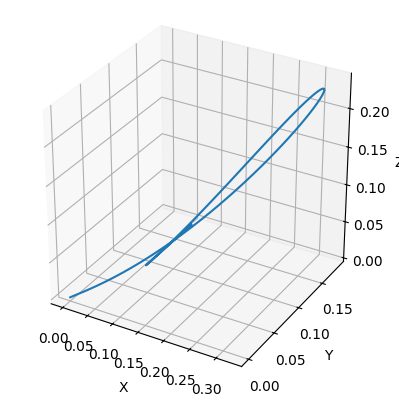

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z[:, 0], z[:, 1], z[:, 2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set axes to have equal aspect ratio
plt.show()

# Run MPC

In [ ]:
# Generate reference trajectory
dt = 0.01
T_f = 2.5
t_mpc = jnp.arange(0, T_f+dt, dt)
traj_type = 'figure_eight'
if traj_type == 'figure_eight':
    z_ref = generate_ref_trajectory(t_mpc, type=traj_type, T=T_f, A=0.125, dim=3)
    #z_ref = generate_ref_trajectory(t_mpc, type=traj_type, T=T_f, A=0.15, dim=3) # Patrick comparison
elif traj_type == 'circle':
    z_ref = generate_ref_trajectory(t_mpc, type=traj_type, T=T_f, A=0.2, dim=3)

In [ ]:
# Set MPC parameters
u_scale = 0.1
ρ, dρ = 1e-7, 1e-3  # using 0.001 in Patrick's code
R = ρ * u_scale**2 * jnp.eye(ssmr_orth.n_u)
R_du = dρ * u_scale**2 * jnp.eye(ssmr_orth.n_u)
Q = jnp.eye(ssmr_orth.n_z) # using 1e4 in Patrick's code
Q = Q.at[2, 2].set(0.0)
gusto_config_orth = GuSTOConfig(
    Qz=Q,
    Qzf=Q,
    R=R,
    R_du=R_du,
    x_char=jnp.ones(ssmr_orth.n_x),
    f_char=jnp.ones(ssmr_orth.n_x),
    N=8,
    dt=dt
)
gusto_config_opt = GuSTOConfig(
    Qz=Q,
    Qzf=5*Q if traj_type == 'figure_eight' else Q,
    R=10*R,
    R_du=R_du,
    x_char=jnp.ones(ssmr_opt.n_x),
    f_char=jnp.ones(ssmr_opt.n_x),
    N=8,
    dt=dt
)

In [ ]:
# Solve MPC problem
U = HyperRectangle([20.0] * 6, [-20.0] * 6)  # set bounds on control inputs if desired (not tight here)
x_mpc_orth, z_mpc_orth, u_mpc_orth, z_true_orth = run_mpc(
    trunk,
    ssmr_orth,
    gusto_config_orth,
    z_ref,
    U=U,
    dU=None,
    N_exec=2)
x_mpc_opt, z_mpc_opt, u_mpc_opt, z_true_opt = run_mpc(
    trunk,
    ssmr_opt,
    gusto_config_opt,
    z_ref,
    U=U,
    dU=None,
    N_exec=2)

[ 2.1410340e-03  7.4325231e-05 -2.8640893e-04 -1.8604273e-03
  3.2169337e-04] [[ 2.1410340e-03  7.4325231e-05 -2.8640893e-04 -1.8604273e-03
   3.2169337e-04]
 [ 2.1557533e-03  1.1690534e-04 -2.9096438e-04 -1.8185809e-03
   2.9499951e-04]
 [ 2.1574409e-03  1.5620244e-04 -2.9235324e-04 -1.7700481e-03
   2.7037496e-04]
 [ 2.1462739e-03  1.9217706e-04 -2.9070690e-04 -1.7149883e-03
   2.4769179e-04]
 [ 2.1225014e-03  2.2480325e-04 -2.8616822e-04 -1.6536036e-03
   2.2683035e-04]
 [ 2.0864424e-03  2.5406893e-04 -2.7889071e-04 -1.5861371e-03
   2.0767865e-04]
 [ 2.0384828e-03  2.7997606e-04 -2.6903790e-04 -1.5128700e-03
   1.9013163e-04]
 [ 1.9790723e-03  3.0254072e-04 -2.5678240e-04 -1.4341193e-03
   1.7409062e-04]
 [ 1.9087214e-03  3.2179320e-04 -2.4230497e-04 -1.3502353e-03
   1.5946272e-04]]
First solve may take a while due to factorization and caching.
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver stat

  3%|▎         | 8/242 [00:00<00:03, 76.78it/s]

Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start fail

 13%|█▎        | 31/242 [00:00<00:02, 102.17it/s]

Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start fail

...

Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start fail

 89%|████████▉ | 215/242 [00:01<00:00, 108.51it/s]

Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start fail

100%|██████████| 242/242 [00:02<00:00, 108.26it/s]

Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start failed, so turning off
Solver still failed, returning inf
Iteration 0 of problem cannot be solved, see solver status for more information
Solving with warm-start fail

In [ ]:
# Compute integrated squared error
def compute_ise(i_start, i_end, z_ref, z_true, dim=2):
    if dim == 2:
        return jnp.sum((jnp.linalg.norm(z_true[i_start:i_end, :2] - z_ref[i_start:i_end, :2], axis=1)) ** 2 * dt)
    elif dim == 3:
        return jnp.sum((jnp.linalg.norm(z_true[i_start:i_end, :3] - z_ref[i_start:i_end, :3], axis=1)) ** 2 * dt)

if traj_type == 'circle':
    i_start = 15
elif traj_type == 'figure_eight':
    i_start = 0

ise_orth = compute_ise(i_start, -gusto_config_orth.N, z_ref, z_true_orth)
ise_opt = compute_ise(i_start, -gusto_config_opt.N, z_ref, z_true_opt)
print("ISE (orthogonal):", ise_orth*10**4, "cm^2")
print("ISE (oblique):", ise_opt*10**4, "cm^2")

ISE (orthogonal): 389.95044 cm^2
ISE (oblique): 389.95044 cm^2


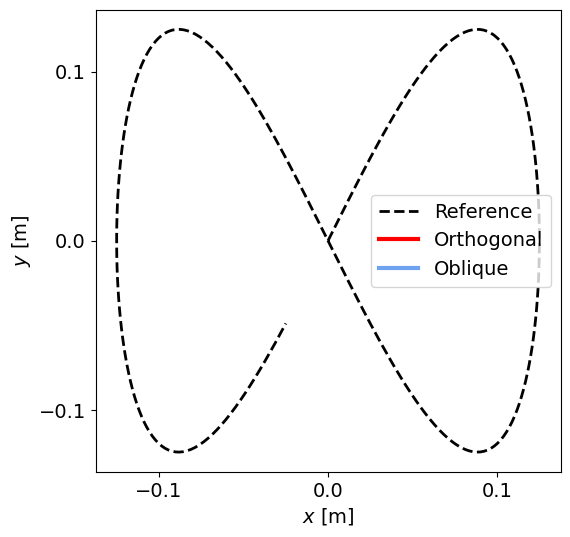

In [ ]:
# Plot the results
plot_trunk_results(z_ref, z_true_orth, z_true_opt, gusto_config_opt.N)